In [4]:
!pip install a2pm -q

In [5]:
import numpy as np
import pandas as pd
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

from a2pm import A2PMethod
from a2pm.patterns import IntervalPattern

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("All imports successful.")

All imports successful.


In [6]:
DATA_PATH = (
    "/content/drive/MyDrive/final_dataset/"
    "iot_cleaned_sampled_smote(hybrid70-30)/"
    "preprocessed_dataset_with_shadow.csv"
)
SAVE_DIR = (
    "/content/drive/MyDrive/final_dataset/"
    "iot_cleaned_sampled_smote(hybrid70-30)/models/adversarial/"
)
os.makedirs(SAVE_DIR, exist_ok=True)

processed_df = pd.read_csv(DATA_PATH)
print(f"Dataset shape : {processed_df.shape}")

label_cols   = ['Binary_Label', 'Superclass', 'Fine_Label']
feature_cols = [c for c in processed_df.columns if c not in label_cols]
print(f"Features ({len(feature_cols)}): {feature_cols}")

X         = processed_df[feature_cols]           # DataFrame
y_binary  = processed_df['Binary_Label'].values  # numpy
s         = processed_df['Superclass']           # Series — may contain NaN
fine_label = processed_df['Fine_Label']

nan_count = s.isna().sum()
print(f"\nClass distribution — Benign: {(y_binary==0).sum():,}  Attack: {(y_binary==1).sum():,}")
print(f"NaN in Superclass (SMOTE artifacts): {nan_count:,}")

# Exact split — must match all other experiments
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y_binary, s,
    test_size=0.2,
    stratify=fine_label,
    random_state=42
)

print(f"\nTrain : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Test  — Attack: {(y_test==1).sum():,}  Benign: {(y_test==0).sum():,}")

Dataset shape : (2884039, 17)
Features (14): ['https', 'ack_flag_number', 'time_to_live', 'iat', 'rate', 'psh_flag_number', 'max', 'ack_count', 'header_length', 'tot sum', 'avg', 'syn_flag_number', 'min', 'variance']

Class distribution — Benign: 1,026,155  Attack: 1,857,884
NaN in Superclass (SMOTE artifacts): 30,000

Train : 2,307,231  |  Test : 576,808
Test  — Attack: 371,577  Benign: 205,231


In [7]:
MODEL_PATH = (
    "/content/drive/MyDrive/final_dataset/"
    "iot_cleaned_sampled_smote(hybrid70-30)/models/xgboost_model.pkl"
)

with open(MODEL_PATH, 'rb') as f:
    xgb_model = pickle.load(f)
print(f"Model loaded: {type(xgb_model).__name__}")

y_pred_clean = xgb_model.predict(X_test).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_clean, labels=[0, 1]).ravel()
baseline_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_clean),
    'F1'       : f1_score(y_test, y_pred_clean, zero_division=0),
    'FNR'      : fn / (fn + tp),
    'FPR'      : fp / (fp + tn),
    'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
}

print(f"\n{'='*45}")
print("  Baseline XGBoost — Clean Test Data")
print(f"{'='*45}")
print(f"  Accuracy : {baseline_metrics['Accuracy']*100:.2f}%")
print(f"  F1       : {baseline_metrics['F1']:.4f}")
print(f"  FNR      : {baseline_metrics['FNR']*100:.2f}%")
print(f"  FPR      : {baseline_metrics['FPR']*100:.4f}%")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")


Model loaded: XGBClassifier

  Baseline XGBoost — Clean Test Data
  Accuracy : 92.60%
  F1       : 0.9412
  FNR      : 8.16%
  FPR      : 6.0074%
  TP=341247  TN=192902  FP=12329  FN=30330


In [8]:
def evaluate(y_true, y_pred, label=""):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics = dict(
        Label=label, Accuracy=acc, F1=f1, FNR=fnr, FPR=fpr,
        TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn)
    )
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc*100:.2f}%   F1 : {f1:.4f}")
    print(f"  FNR      : {fnr*100:.2f}%   FPR: {fpr*100:.4f}%")
    print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    return metrics


def superclass_breakdown(y_pred, s_labels, y_true, title=""):
    """
    Per-superclass detection rate table.
    NaN superclass rows (SMOTE artifacts) are excluded from the table
    but are included in all aggregate metrics — they are noted in output.
    """
    y_true  = np.asarray(y_true)
    y_pred  = np.asarray(y_pred)
    s_str   = pd.Series(np.asarray(s_labels, dtype=object)).astype(str).reset_index(drop=True)

    nan_attack_count = ((s_str == 'nan') & (y_true == 1)).sum()
    if nan_attack_count > 0:
        print(f"\n  [{title}] Note: {nan_attack_count} attack samples have NaN Superclass "
              f"(SMOTE artifacts) — excluded from table below, included in all metrics.")

    valid   = (~(s_str == 'nan')) & (y_true == 1)
    classes = sorted(s_str[valid].unique())

    rows = []
    for cls in classes:
        m         = (s_str == cls) & (y_true == 1)
        total     = int(m.sum())
        detected  = int((y_pred[m] == 1).sum())
        evaded    = total - detected
        dr        = detected / total if total > 0 else 0.0
        rows.append({
            'Superclass'     : cls,
            'Total'          : total,
            'Detected'       : detected,
            'Evaded'         : evaded,
            'Detection Rate' : f"{dr:.1%}",
        })

    df = pd.DataFrame(rows)
    print(f"\n{title}")
    print(df.to_string(index=False))
    return df


def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Benign', 'Attack'],
        yticklabels=['Benign', 'Attack'],
        cbar=False
    )
    ax.set_title(f"{title}\nFNR={fnr:.2%}  FPR={fpr:.4%}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

print("Helpers defined.")


Helpers defined.


In [9]:
attack_mask    = (y_test == 1)          # numpy boolean array
benign_mask    = (y_test == 0)

X_test_attack  = X_test[attack_mask]   # DataFrame — attack rows of test set
X_train_attack = X_train[y_train == 1] # DataFrame — attack rows of train set

print(f"Test attack samples  : {len(X_test_attack):,}")
print(f"Train attack samples : {len(X_train_attack):,}")

# Bounds computed from training attack samples only (not the full training set)
feat_min = X_train_attack.min()
feat_max = X_train_attack.max()

bounds_df = pd.DataFrame({
    'Feature'         : feature_cols,
    'Train_Attack_Min': feat_min.values,
    'Train_Attack_Max': feat_max.values,
    'Range'           : (feat_max - feat_min).values,
})
print("\nFeature bounds (from training attack samples):")
print(bounds_df.to_string(index=False))


Test attack samples  : 371,577
Train attack samples : 1,486,307

Feature bounds (from training attack samples):
        Feature  Train_Attack_Min  Train_Attack_Max        Range
          https          0.000000              1.00 1.000000e+00
ack_flag_number          0.000000              1.00 1.000000e+00
   time_to_live          0.000000            255.00 2.550000e+02
            iat          0.000000          46665.21 4.666521e+04
           rate          0.000021        7340032.00 7.340032e+06
psh_flag_number          0.000000              1.00 1.000000e+00
            max         46.000000          43506.00 4.346000e+04
      ack_count          0.000000            100.00 1.000000e+02
  header_length          0.000000             60.00 6.000000e+01
        tot sum         60.000000         316492.00 3.164320e+05
            avg         46.000000           5022.00 4.976000e+03
syn_flag_number          0.000000              1.00 1.000000e+00
            min         42.000000          

In [10]:
class XGBWrapper:
    """Wraps XGBoost so A2PM can call .predict() and receive integer labels."""
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return self.model.predict(X).astype(int)


xgb_wrapper = XGBWrapper(xgb_model)

# Single IntervalPattern covering all 15 features
pattern = IntervalPattern(
    ratio       = 0.1,   # perturbation step as fraction of each feature's interval
    probability = 0.7,   # per-feature perturbation probability per iteration
    momentum    = 0.99,
    seed        = 42,
)

a2pm_model = A2PMethod(pattern=pattern, seed=42)

# Fit on training attack samples — learns valid interval per feature
print("Fitting A2PM on training attack samples...")
a2pm_model.fit(
    X_train_attack.values,
    y=np.ones(len(X_train_attack), dtype=int),
)
print("Fit complete.\n")

# Generate: y_target=0 means perturb until classifier predicts Benign (evasion)
print(f"Generating adversarial samples for {len(X_test_attack):,} attack samples ...")
print("(iterations=10, patience=2 — may take several minutes)\n")

X_adv = a2pm_model.generate(
    classifier = xgb_wrapper,
    X          = X_test_attack.values,
    y          = np.ones(len(X_test_attack), dtype=int),
    y_target   = np.zeros(len(X_test_attack), dtype=int),
    iterations = 30,
    patience   = 5,
)

print(f"Generation complete.  Shape: {X_adv.shape}")

# Per-sample perturbation delta — used in Cells 7, 8, 11
delta = X_adv - X_test_attack.values   # (n_attack, n_features)

# Reconstruct full test set: benign rows unchanged, attack rows replaced
X_full_adv_values            = X_test.values.copy()
X_full_adv_values[attack_mask] = X_adv
X_full_adv = pd.DataFrame(X_full_adv_values, columns=feature_cols, index=X_test.index)

# Evaluate
y_pred_a2pm = xgb_model.predict(X_full_adv).astype(int)
a2pm_metrics = evaluate(y_test, y_pred_a2pm, "A2PM Adversarial Attack (full test set)")

# Evasion rate on attack subset only
evasion_rate = (y_pred_a2pm[attack_mask] == 0).mean()
print(f"\n  Attack-subset evasion rate : {evasion_rate:.2%}  "
      f"({int(evasion_rate * attack_mask.sum())} / {attack_mask.sum()} attacks evade detection)")

# Robustness gap vs clean baseline
rob_gap_acc = baseline_metrics['Accuracy'] - a2pm_metrics['Accuracy']
rob_gap_fnr = a2pm_metrics['FNR']          - baseline_metrics['FNR']

print(f"\n{'─'*45}")
print("  Robustness Gap  (A2PM vs Clean)")
print(f"{'─'*45}")
print(f"  Accuracy drop   : {rob_gap_acc*100:.2f} pp")
print(f"  FNR increase    : {rob_gap_fnr*100:.2f} pp")
print(f"\n  FGSM/BIM ref    : ~0.00 pp  (gradient collapse, 99.8% zero grads)")
print(f"  A2PM gap        : {rob_gap_acc*100:.2f} pp  ← genuine robustness deficit")


Fitting A2PM on training attack samples...
Fit complete.

Generating adversarial samples for 371,577 attack samples ...
(iterations=10, patience=2 — may take several minutes)

Generation complete.  Shape: (371577, 14)

  A2PM Adversarial Attack (full test set)
  Accuracy : 82.07%   F1 : 0.8444
  FNR      : 24.51%   FPR: 6.0074%
  TP=280494  TN=192902  FP=12329  FN=91083

  Attack-subset evasion rate : 24.51%  (91083 / 371577 attacks evade detection)

─────────────────────────────────────────────
  Robustness Gap  (A2PM vs Clean)
─────────────────────────────────────────────
  Accuracy drop   : 10.53 pp
  FNR increase    : 16.35 pp

  FGSM/BIM ref    : ~0.00 pp  (gradient collapse, 99.8% zero grads)
  A2PM gap        : 10.53 pp  ← genuine robustness deficit


In [11]:
# delta is available from Cell 6: X_adv - X_test_attack.values

violations_per_feature = {}
for i, feat in enumerate(feature_cols):
    below = int((X_adv[:, i] < feat_min[feat]).sum())
    above = int((X_adv[:, i] > feat_max[feat]).sum())
    violations_per_feature[feat] = {
        'Below Min'        : below,
        'Above Max'        : above,
        'Total Violations' : below + above,
        'Mean |Δ|'         : np.abs(delta[:, i]).mean(),
    }

total_cells = X_adv.shape[0] * X_adv.shape[1]
total_viols = sum(v['Total Violations'] for v in violations_per_feature.values())
viol_rate   = total_viols / total_cells

print(f"\n{'='*55}")
print("  Realism Check — A2PM Adversarial Samples")
print(f"{'='*55}")
print(f"  Adversarial samples  : {X_adv.shape[0]:,}")
print(f"  Total feature cells  : {total_cells:,}")
print(f"  Constraint violations: {total_viols}  ({viol_rate:.2%})")
print(f"\n  FGSM/BIM reference   : 62.3%  (floating-point artifacts, mean|Δ|≈0)")
print(f"  A2PM violation rate  : {viol_rate:.2%}  ← near 0% (genuinely constrained)")

viol_df = pd.DataFrame([
    {
        'Feature'          : feat,
        'Below Min'        : v['Below Min'],
        'Above Max'        : v['Above Max'],
        'Total Violations' : v['Total Violations'],
        'Mean |Δ|'         : f"{v['Mean |Δ|']:.6f}",
    }
    for feat, v in violations_per_feature.items()
])
print("\nPer-feature violation breakdown:")
print(viol_df.to_string(index=False))

# Sample-level: how many adversarial samples are fully in-bounds?
sample_viols = np.array([
    sum(
        1 for i, feat in enumerate(feature_cols)
        if X_adv[j, i] < feat_min[feat] or X_adv[j, i] > feat_max[feat]
    )
    for j in range(X_adv.shape[0])
])
in_bounds = (sample_viols == 0).sum()
print(f"\n  Samples fully in-bounds : {in_bounds:,} / {len(sample_viols):,}  "
      f"({in_bounds/len(sample_viols):.1%})")
print(f"  Max violations per sample : {sample_viols.max()}")



  Realism Check — A2PM Adversarial Samples
  Adversarial samples  : 371,577
  Total feature cells  : 5,202,078
  Constraint violations: 0  (0.00%)

  FGSM/BIM reference   : 62.3%  (floating-point artifacts, mean|Δ|≈0)
  A2PM violation rate  : 0.00%  ← near 0% (genuinely constrained)

Per-feature violation breakdown:
        Feature  Below Min  Above Max  Total Violations        Mean |Δ|
          https          0          0                 0        0.282524
ack_flag_number          0          0                 0        0.270572
   time_to_live          0          0                 0       53.636122
            iat          0          0                 0    13667.001021
           rate          0          0                 0  2016734.946770
psh_flag_number          0          0                 0        0.279261
            max          0          0                 0    12576.024860
      ack_count          0          0                 0       26.715180
  header_length          0       

In [12]:
# delta from Cell 6
abs_delta = np.abs(delta)
changed   = abs_delta > 0   # boolean mask

print(f"\n{'='*55}")
print("  Perturbation Analysis — A2PM")
print(f"{'='*55}")

feat_rows = [
    {
        'Feature'            : feat,
        'Mean |Δ|'           : f"{abs_delta[:, i].mean():.6f}",
        '% Samples Changed'  : f"{changed[:, i].mean()*100:.1f}%",
    }
    for i, feat in enumerate(feature_cols)
]
print("\nPer-feature statistics:")
print(pd.DataFrame(feat_rows).to_string(index=False))

n_changed = changed.sum(axis=1)   # features changed per sample
print(f"\nFeatures perturbed per adversarial sample:")
print(f"  Mean   : {n_changed.mean():.2f} / {len(feature_cols)}")
print(f"  Median : {np.median(n_changed):.1f}")
print(f"  Range  : {n_changed.min()} – {n_changed.max()}")
print(f"  Samples with 0 features changed : {(n_changed==0).sum():,}  "
      f"({(n_changed==0).mean():.1%})  ← already evading before perturbation")

print("\nDistribution (features changed per sample):")
for k in range(len(feature_cols) + 1):
    cnt = int((n_changed == k).sum())
    if cnt == 0:
        continue
    bar = '█' * max(1, int(cnt / len(n_changed) * 40))
    print(f"  {k:2d} features : {cnt:5,}  {bar}")

global_mean = abs_delta.mean()
print(f"\nGlobal mean |Δ|  : {global_mean:.6f}")
print(f"FGSM reference   : ≈0.000000  (zero gradients → no real perturbation)")
print(f"A2PM             : {global_mean:.6f}  ← genuine, measurable perturbations")



  Perturbation Analysis — A2PM

Per-feature statistics:
        Feature        Mean |Δ| % Samples Changed
          https        0.282524             85.4%
ack_flag_number        0.270572             85.8%
   time_to_live       53.636122             86.5%
            iat    13667.001021             91.2%
           rate  2016734.946770             91.2%
psh_flag_number        0.279261             85.8%
            max    12576.024860             90.3%
      ack_count       26.715180             80.8%
  header_length       13.783672             86.4%
        tot sum    82419.347404             90.3%
            avg     1345.342344             90.8%
syn_flag_number        0.280006             83.9%
            min      939.944322             89.4%
       variance 24197699.144641             88.2%

Features perturbed per adversarial sample:
  Mean   : 12.26 / 14
  Median : 14.0
  Range  : 0 – 14
  Samples with 0 features changed : 30,330  (8.2%)  ← already evading before perturbation

Di

In [13]:
# Align indices for superclass_breakdown
s_test_arr = np.asarray(s_test)
y_test_arr = y_test   # already numpy

print("\n" + "="*60)
print("  SUPERCLASS DETECTION BREAKDOWN")
print("="*60)

df_clean_sc = superclass_breakdown(
    y_pred    = y_pred_clean,
    s_labels  = s_test_arr,
    y_true    = y_test_arr,
    title     = "CLEAN BASELINE — per-superclass detection rate",
)

df_a2pm_sc = superclass_breakdown(
    y_pred    = y_pred_a2pm,
    s_labels  = s_test_arr,
    y_true    = y_test_arr,
    title     = "A2PM ATTACK — per-superclass detection rate",
)

# Per-superclass evasion rate (which attack families evade most)
print("\nPer-superclass evasion rate after A2PM:")
evasion_rows = []
for _, row_c in df_clean_sc.iterrows():
    cls   = row_c['Superclass']
    total = row_c['Total']
    det_c = row_c['Detected']
    match = df_a2pm_sc[df_a2pm_sc['Superclass'] == cls]
    det_a = match.iloc[0]['Detected'] if len(match) > 0 else det_c
    evasion = (total - det_a) / total if total > 0 else 0.0
    evasion_rows.append({
        'Superclass'      : cls,
        'Total'           : total,
        'Detected (Clean)': det_c,
        'Detected (A2PM)' : det_a,
        'Evaded (A2PM)'   : total - det_a,
        'Evasion Rate'    : f"{evasion:.1%}",
    })

evasion_df = pd.DataFrame(evasion_rows).sort_values('Evasion Rate', ascending=False)
print(evasion_df.to_string(index=False))



  SUPERCLASS DETECTION BREAKDOWN

  [CLEAN BASELINE — per-superclass detection rate] Note: 6000 attack samples have NaN Superclass (SMOTE artifacts) — excluded from table below, included in all metrics.

CLEAN BASELINE — per-superclass detection rate
 Superclass  Total  Detected  Evaded Detection Rate
Brute Force   6000      4605    1395          76.8%
       DDoS 145194    145194       0         100.0%
        DoS  46589     46588       1         100.0%
      Mirai  41966     41966       0         100.0%
      Recon  61911     39561   22350          63.9%
   Spoofing  27967     24057    3910          86.0%
  Web-based  35950     33277    2673          92.6%

  [A2PM ATTACK — per-superclass detection rate] Note: 6000 attack samples have NaN Superclass (SMOTE artifacts) — excluded from table below, included in all metrics.

A2PM ATTACK — per-superclass detection rate
 Superclass  Total  Detected  Evaded Detection Rate
Brute Force   6000      3514    2486          58.6%
       DDoS 1451

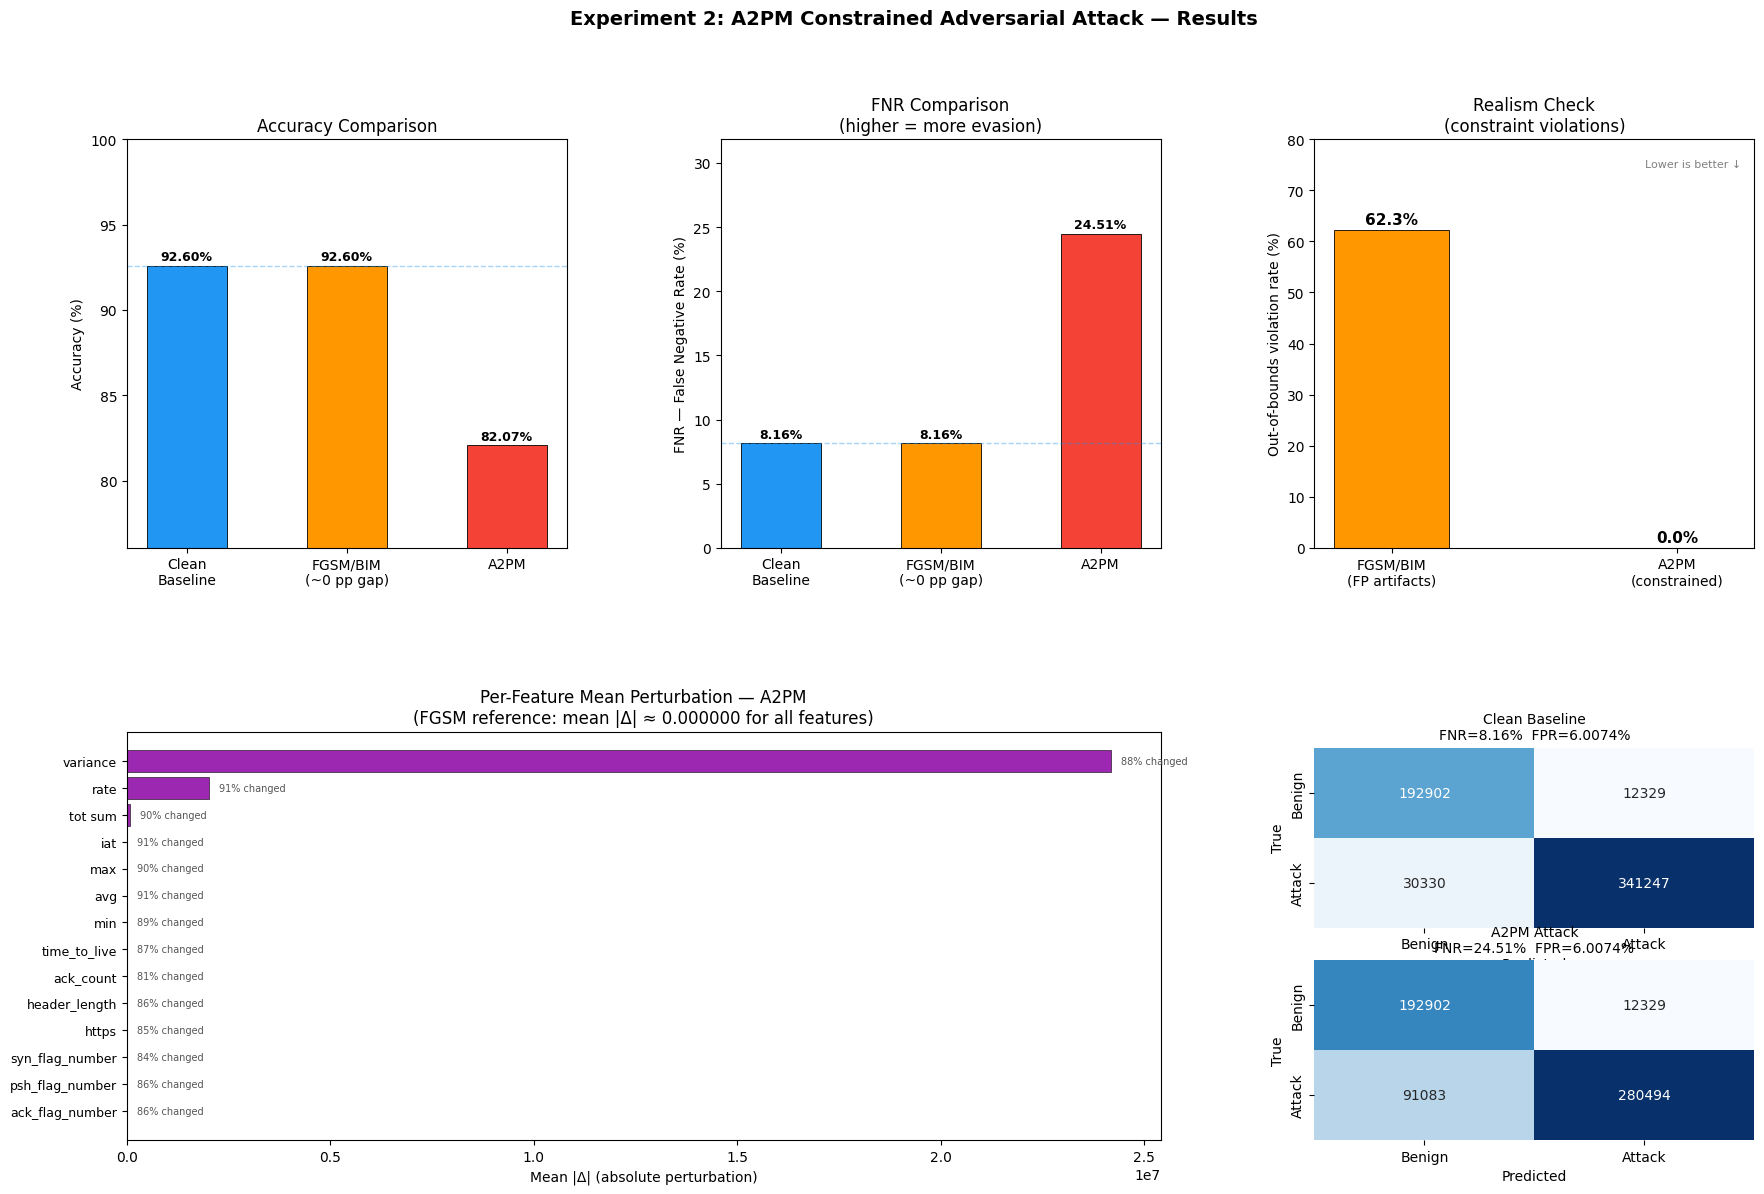

Figure saved.


In [14]:
FGSM_ACC      = baseline_metrics['Accuracy']   # ~0 pp gap
FGSM_FNR      = baseline_metrics['FNR']        # ~0 pp gap
FGSM_VIOL_PCT = 62.3                           # % from Experiment 1

fig = plt.figure(figsize=(21, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    "Experiment 2: A2PM Constrained Adversarial Attack — Results",
    fontsize=14, fontweight='bold',
)

COLORS = {'clean': '#2196F3', 'fgsm': '#FF9800', 'a2pm': '#F44336'}

# ── Row 0, Col 0 — Accuracy comparison ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
labs   = ['Clean\nBaseline', 'FGSM/BIM\n(~0 pp gap)', 'A2PM']
acc_v  = [
    baseline_metrics['Accuracy'] * 100,
    FGSM_ACC * 100,
    a2pm_metrics['Accuracy'] * 100,
]
bars = ax.bar(labs, acc_v,
              color=[COLORS['clean'], COLORS['fgsm'], COLORS['a2pm']],
              edgecolor='black', linewidth=0.6, width=0.5)
for bar, val in zip(bars, acc_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(max(0, min(acc_v) - 6), 100)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Comparison")
ax.axhline(baseline_metrics['Accuracy'] * 100, color=COLORS['clean'],
           linestyle='--', alpha=0.4, linewidth=1)

# ── Row 0, Col 1 — FNR comparison ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
fnr_v = [
    baseline_metrics['FNR'] * 100,
    FGSM_FNR * 100,
    a2pm_metrics['FNR'] * 100,
]
bars = ax.bar(labs, fnr_v,
              color=[COLORS['clean'], COLORS['fgsm'], COLORS['a2pm']],
              edgecolor='black', linewidth=0.6, width=0.5)
for bar, val in zip(bars, fnr_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(fnr_v) * 1.3)
ax.set_ylabel("FNR — False Negative Rate (%)")
ax.set_title("FNR Comparison\n(higher = more evasion)")
ax.axhline(baseline_metrics['FNR'] * 100, color=COLORS['clean'],
           linestyle='--', alpha=0.4, linewidth=1)

# ── Row 0, Col 2 — Realism violations ──────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
viol_labels = ['FGSM/BIM\n(FP artifacts)', 'A2PM\n(constrained)']
viol_vals   = [FGSM_VIOL_PCT, viol_rate * 100]
bars = ax.bar(viol_labels, viol_vals,
              color=['#FF9800', '#4CAF50'],
              edgecolor='black', linewidth=0.6, width=0.4)
for bar, val in zip(bars, viol_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 80)
ax.set_ylabel("Out-of-bounds violation rate (%)")
ax.set_title("Realism Check\n(constraint violations)")
ax.text(0.97, 0.95, "Lower is better ↓", transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='gray')

# ── Row 1, Col 0–1 — Per-feature mean perturbation ─────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
mean_perturb  = abs_delta.mean(axis=0)
sort_idx      = np.argsort(mean_perturb)[::-1]
feat_sorted   = [feature_cols[i] for i in sort_idx]
perturb_sorted = mean_perturb[sort_idx]
pct_changed   = changed.mean(axis=0)[sort_idx] * 100

bars = ax.barh(range(len(feature_cols)), perturb_sorted,
               color='#9C27B0', edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feat_sorted, fontsize=9)
ax.set_xlabel("Mean |Δ| (absolute perturbation)")
ax.set_title("Per-Feature Mean Perturbation — A2PM\n"
             "(FGSM reference: mean |Δ| ≈ 0.000000 for all features)")
ax.invert_yaxis()
# Annotate % samples changed
for i, (val, pct) in enumerate(zip(perturb_sorted, pct_changed)):
    ax.text(val + max(perturb_sorted) * 0.01, i,
            f'{pct:.0f}% changed', va='center', fontsize=7, color='#555')

# ── Row 1, Col 2 — Confusion matrices (Clean & A2PM stacked) ───────────────
# Use inset axes to fit both CMs in one subplot cell
ax_parent = fig.add_subplot(gs[1, 2])
ax_parent.axis('off')

# We add two real axes manually positioned inside this subplot's bounding box
pos   = ax_parent.get_position()
left, bottom, w, h = pos.x0, pos.y0, pos.width, pos.height

ax_cm0 = fig.add_axes([left,          bottom + h*0.52, w, h*0.44])
ax_cm1 = fig.add_axes([left,          bottom,           w, h*0.44])

plot_cm(y_test, y_pred_clean, "Clean Baseline", ax_cm0)
plot_cm(y_test, y_pred_a2pm,  "A2PM Attack",    ax_cm1)

plt.savefig(
    os.path.join(SAVE_DIR, "experiment2_a2pm_results.png"),
    dpi=150, bbox_inches='tight',
)
plt.show()
print("Figure saved.")


In [15]:
summary_df = pd.DataFrame([
    {
        'Experiment'             : 'Clean Baseline',
        'Method'                 : 'XGBoost (no attack)',
        'Accuracy'               : f"{baseline_metrics['Accuracy']*100:.2f}%",
        'F1'                     : f"{baseline_metrics['F1']:.4f}",
        'FNR'                    : f"{baseline_metrics['FNR']*100:.2f}%",
        'FPR'                    : f"{baseline_metrics['FPR']*100:.4f}%",
        'Robustness Gap (Acc)'   : '—',
        'Robustness Gap (FNR)'   : '—',
        'Realism Violations'     : '—',
        'Global Mean |Δ|'        : '—',
        'Gradient Zero Rate'     : '—',
    },
    {
        'Experiment'             : 'Exp 1 — FGSM/BIM',
        'Method'                 : 'Finite-diff gradient approx',
        'Accuracy'               : f"~{baseline_metrics['Accuracy']*100:.2f}%",
        'F1'                     : f"~{baseline_metrics['F1']:.4f}",
        'FNR'                    : f"~{baseline_metrics['FNR']*100:.2f}%",
        'FPR'                    : f"~{baseline_metrics['FPR']*100:.4f}%",
        'Robustness Gap (Acc)'   : '~0.00 pp',
        'Robustness Gap (FNR)'   : '~0.00 pp',
        'Realism Violations'     : '62.3% (FP artifacts)',
        'Global Mean |Δ|'        : '≈0.000000 (zero grads)',
        'Gradient Zero Rate'     : '99.8%',
    },
    {
        'Experiment'             : 'Exp 2 — A2PM',
        'Method'                 : 'Interval pattern (gradient-free)',
        'Accuracy'               : f"{a2pm_metrics['Accuracy']*100:.2f}%",
        'F1'                     : f"{a2pm_metrics['F1']:.4f}",
        'FNR'                    : f"{a2pm_metrics['FNR']*100:.2f}%",
        'FPR'                    : f"{a2pm_metrics['FPR']*100:.4f}%",
        'Robustness Gap (Acc)'   : f"{rob_gap_acc*100:.2f} pp",
        'Robustness Gap (FNR)'   : f"{rob_gap_fnr*100:.2f} pp",
        'Realism Violations'     : f"{viol_rate:.2%}",
        'Global Mean |Δ|'        : f"{abs_delta.mean():.6f}",
        'Gradient Zero Rate'     : 'N/A (gradient-free)',
    },
])

print("\nEXPERIMENT SUMMARY")
print("="*120)
print(summary_df.to_string(index=False))

# ── Save outputs ─────────────────────────────────────────────────────────────
summary_df.to_csv(os.path.join(SAVE_DIR, "experiment_summary.csv"), index=False)
print(f"\nSummary      → {SAVE_DIR}experiment_summary.csv")

# Full adversarial test set with predictions
adv_out                = X_full_adv.copy()
adv_out['y_true']      = y_test
adv_out['y_pred_clean']= y_pred_clean
adv_out['y_pred_a2pm'] = y_pred_a2pm
adv_out['Superclass']  = np.asarray(s_test)
adv_out.to_csv(os.path.join(SAVE_DIR, "a2pm_adversarial_test_set.csv"), index=False)
print(f"Adv test set → {SAVE_DIR}a2pm_adversarial_test_set.csv")

# Raw perturbation deltas (attack samples only)
delta_df = pd.DataFrame(delta, columns=feature_cols)
delta_df.to_csv(os.path.join(SAVE_DIR, "a2pm_perturbations_delta.csv"), index=False)
print(f"Deltas       → {SAVE_DIR}a2pm_perturbations_delta.csv")

# Evasion breakdown by superclass
evasion_df.to_csv(os.path.join(SAVE_DIR, "a2pm_superclass_evasion.csv"), index=False)
print(f"Superclass   → {SAVE_DIR}a2pm_superclass_evasion.csv")

print(f"\nAll outputs saved to: {SAVE_DIR}")



EXPERIMENT SUMMARY
      Experiment                           Method Accuracy      F1    FNR      FPR Robustness Gap (Acc) Robustness Gap (FNR)   Realism Violations        Global Mean |Δ|  Gradient Zero Rate
  Clean Baseline              XGBoost (no attack)   92.60%  0.9412  8.16%  6.0074%                    —                    —                    —                      —                   —
Exp 1 — FGSM/BIM      Finite-diff gradient approx  ~92.60% ~0.9412 ~8.16% ~6.0074%             ~0.00 pp             ~0.00 pp 62.3% (FP artifacts) ≈0.000000 (zero grads)               99.8%
    Exp 2 — A2PM Interval pattern (gradient-free)   82.07%  0.8444 24.51%  6.0074%             10.53 pp             16.35 pp                0.00%         1880391.214193 N/A (gradient-free)

Summary      → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid70-30)/models/adversarial/experiment_summary.csv
Adv test set → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid70-30)

In [16]:
import numpy as np
import pandas as pd

# Use your X_adv from Cell 6 (ratio=0.1 run)
# and X_test_attack.values as originals

fi = {f: i for i, f in enumerate(feature_cols)}

print("=" * 65)
print("CONSTRAINT VIOLATION CHECK — A2PM Generated Samples")
print("=" * 65)
print(f"Checking {len(X_adv):,} adversarial attack samples\n")

results = []

# ── Check 1: min <= avg <= max ────────────────────────────────────────────────
if all(f in fi for f in ['min', 'avg', 'max']):
    i_min = fi['min']
    i_avg = fi['avg']
    i_max = fi['max']

    avg_below_min = int((X_adv[:, i_avg] < X_adv[:, i_min]).sum())
    avg_above_max = int((X_adv[:, i_avg] > X_adv[:, i_max]).sum())
    min_above_max = int((X_adv[:, i_min] > X_adv[:, i_max]).sum())

    print(f"Constraint 1 — Packet size ordering (min ≤ avg ≤ max)")
    print(f"  avg < min (impossible) : {avg_below_min:,} samples "
          f"({avg_below_min/len(X_adv)*100:.2f}%)")
    print(f"  avg > max (impossible) : {avg_above_max:,} samples "
          f"({avg_above_max/len(X_adv)*100:.2f}%)")
    print(f"  min > max (impossible) : {min_above_max:,} samples "
          f"({min_above_max/len(X_adv)*100:.2f}%)")
    results.append(('avg < min', avg_below_min))
    results.append(('avg > max', avg_above_max))
    results.append(('min > max', min_above_max))

# ── Check 2: variance >= 0 ────────────────────────────────────────────────────
if 'variance' in fi:
    i_var   = fi['variance']
    # In RobustScaled space, find what 0 maps to
    # variance=0 in original maps to (0 - median) / IQR in scaled space
    # The minimum observed in training is our proxy for the scaled zero
    var_min_train = float(feat_min['variance'])
    neg_var = int((X_adv[:, i_var] < var_min_train).sum())
    print(f"\nConstraint 2 — Variance ≥ 0 (scaled minimum = {var_min_train:.4f})")
    print(f"  Below scaled minimum   : {neg_var:,} samples "
          f"({neg_var/len(X_adv)*100:.2f}%)")
    results.append(('variance < min', neg_var))

# ── Check 3: flag counts <= packet count ──────────────────────────────────────
if 'number' in fi:
    i_num = fi['number']
    print(f"\nConstraint 3 — Flag counts ≤ packet count (number)")
    for flag in ['ack_flag_number', 'psh_flag_number',
                 'syn_flag_number', 'ack_count']:
        if flag in fi:
            i_flag   = fi[flag]
            violated = int((X_adv[:, i_flag] > X_adv[:, i_num]).sum())
            print(f"  {flag:<25} > number : {violated:,} samples "
                  f"({violated/len(X_adv)*100:.2f}%)")
            results.append((f'{flag} > number', violated))

# ── Check 4: header_length <= min packet size ─────────────────────────────────
if 'header_length' in fi and 'min' in fi:
    i_hdr    = fi['header_length']
    i_min    = fi['min']
    violated = int((X_adv[:, i_hdr] > X_adv[:, i_min]).sum())
    print(f"\nConstraint 4 — header_length ≤ min packet size")
    print(f"  header_length > min    : {violated:,} samples "
          f"({violated/len(X_adv)*100:.2f}%)")
    results.append(('header_length > min', violated))

# ── Check 5: rate and iat directional consistency ─────────────────────────────
if 'rate' in fi and 'iat' in fi:
    i_rate = fi['rate']
    i_iat  = fi['iat']
    orig   = X_test_attack.values

    rate_up_iat_up   = int(((X_adv[:, i_rate] > orig[:, i_rate]) &
                             (X_adv[:, i_iat]  > orig[:, i_iat])).sum())
    rate_down_iat_down = int(((X_adv[:, i_rate] < orig[:, i_rate]) &
                               (X_adv[:, i_iat]  < orig[:, i_iat])).sum())

    print(f"\nConstraint 5 — Rate ↑ implies IAT ↓  (inverse relationship)")
    print(f"  rate↑ AND iat↑ (impossible) : {rate_up_iat_up:,} samples "
          f"({rate_up_iat_up/len(X_adv)*100:.2f}%)")
    print(f"  rate↓ AND iat↓ (impossible) : {rate_down_iat_down:,} samples "
          f"({rate_down_iat_down/len(X_adv)*100:.2f}%)")
    results.append(('rate↑ iat↑', rate_up_iat_up))
    results.append(('rate↓ iat↓', rate_down_iat_down))

# ── Check 6: tot_sum >= max ───────────────────────────────────────────────────
if 'tot_sum' in fi and 'max' in fi:
    i_tot    = fi['tot_sum']
    i_max    = fi['max']
    violated = int((X_adv[:, i_tot] < X_adv[:, i_max]).sum())
    print(f"\nConstraint 6 — tot_sum ≥ max packet size")
    print(f"  tot_sum < max          : {violated:,} samples "
          f"({violated/len(X_adv)*100:.2f}%)")
    results.append(('tot_sum < max', violated))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("SUMMARY")
print(f"{'='*65}")
total_violations = sum(v for _, v in results)
any_violated     = [name for name, v in results if v > 0]

if total_violations == 0:
    print("✅ No constraint violations found.")
    print("   A2PM (ratio=0.1) already respects all logical feature relationships.")
    print("   Hardcoded constraints would make no difference to your results.")
else:
    print(f"Total violations across all constraints : {total_violations:,}")
    print(f"Violated constraints:")
    for name, v in results:
        if v > 0:
            print(f"  {name:<30} : {v:,} samples ({v/len(X_adv)*100:.2f}%)")

CONSTRAINT VIOLATION CHECK — A2PM Generated Samples
Checking 371,577 adversarial attack samples

Constraint 1 — Packet size ordering (min ≤ avg ≤ max)
  avg < min (impossible) : 117,587 samples (31.65%)
  avg > max (impossible) : 33,298 samples (8.96%)
  min > max (impossible) : 29,778 samples (8.01%)

Constraint 2 — Variance ≥ 0 (scaled minimum = 0.0000)
  Below scaled minimum   : 0 samples (0.00%)

Constraint 4 — header_length ≤ min packet size
  header_length > min    : 4,000 samples (1.08%)

Constraint 5 — Rate ↑ implies IAT ↓  (inverse relationship)
  rate↑ AND iat↑ (impossible) : 244,839 samples (65.89%)
  rate↓ AND iat↓ (impossible) : 7,864 samples (2.12%)

SUMMARY
Total violations across all constraints : 437,366
Violated constraints:
  avg < min                      : 117,587 samples (31.65%)
  avg > max                      : 33,298 samples (8.96%)
  min > max                      : 29,778 samples (8.01%)
  header_length > min            : 4,000 samples (1.08%)
  rate↑ iat↑  

In [17]:
print("=" * 65)
print("CONSTRAINT VIOLATION CHECK — ORIGINAL DATA (before any attack)")
print("Checking if violations exist in X_test_attack BEFORE A2PM")
print("=" * 65)
print(f"Checking {len(X_test_attack):,} original attack samples\n")

orig = X_test_attack.values  # original unperturbed attack samples

orig_results = []

# ── Check 1: min <= avg <= max ────────────────────────────────────────────────
if all(f in fi for f in ['min', 'avg', 'max']):
    i_min = fi['min']
    i_avg = fi['avg']
    i_max = fi['max']

    avg_below_min = int((orig[:, i_avg] < orig[:, i_min]).sum())
    avg_above_max = int((orig[:, i_avg] > orig[:, i_max]).sum())
    min_above_max = int((orig[:, i_min] > orig[:, i_max]).sum())

    print(f"Constraint 1 — Packet size ordering (min ≤ avg ≤ max)")
    print(f"  avg < min : {avg_below_min:,}  ({avg_below_min/len(orig)*100:.2f}%)")
    print(f"  avg > max : {avg_above_max:,}  ({avg_above_max/len(orig)*100:.2f}%)")
    print(f"  min > max : {min_above_max:,}  ({min_above_max/len(orig)*100:.2f}%)")
    orig_results.append(('avg < min', avg_below_min))
    orig_results.append(('avg > max', avg_above_max))
    orig_results.append(('min > max', min_above_max))

# ── Check 2: variance ────────────────────────────────────────────────────────
if 'variance' in fi:
    i_var       = fi['variance']
    var_min_train = float(feat_min['variance'])
    neg_var     = int((orig[:, i_var] < var_min_train).sum())
    print(f"\nConstraint 2 — Variance ≥ scaled minimum ({var_min_train:.4f})")
    print(f"  Below scaled minimum : {neg_var:,}  ({neg_var/len(orig)*100:.2f}%)")
    orig_results.append(('variance < min', neg_var))

# ── Check 3: flag counts <= number ───────────────────────────────────────────
if 'number' in fi:
    i_num = fi['number']
    print(f"\nConstraint 3 — Flag counts ≤ number")
    for flag in ['ack_flag_number', 'psh_flag_number',
                 'syn_flag_number', 'ack_count']:
        if flag in fi:
            i_flag   = fi[flag]
            violated = int((orig[:, i_flag] > orig[:, i_num]).sum())
            print(f"  {flag:<25} > number : {violated:,}  "
                  f"({violated/len(orig)*100:.2f}%)")
            orig_results.append((f'{flag} > number', violated))

# ── Check 4: header_length <= min ────────────────────────────────────────────
if 'header_length' in fi and 'min' in fi:
    i_hdr    = fi['header_length']
    i_min    = fi['min']
    violated = int((orig[:, i_hdr] > orig[:, i_min]).sum())
    print(f"\nConstraint 4 — header_length ≤ min")
    print(f"  header_length > min  : {violated:,}  "
          f"({violated/len(orig)*100:.2f}%)")
    orig_results.append(('header_length > min', violated))

# ── Check 5: rate and iat ────────────────────────────────────────────────────
if 'rate' in fi and 'iat' in fi:
    i_rate = fi['rate']
    i_iat  = fi['iat']

    # Compare adjacent samples won't work — check cross correlation instead
    # Across ALL samples: is higher rate associated with lower iat?
    rate_vals = orig[:, i_rate]
    iat_vals  = orig[:, i_iat]
    correlation = np.corrcoef(rate_vals, iat_vals)[0, 1]
    print(f"\nConstraint 5 — Rate vs IAT correlation in original data")
    print(f"  Pearson correlation : {correlation:.4f}")
    print(f"  (Expected negative — higher rate = lower inter-arrival time)")
    print(f"  (Positive correlation would mean the relationship is reversed")
    print(f"   in scaled space, making the directional constraint invalid)")

# ── Check 6: tot_sum >= max ───────────────────────────────────────────────────
if 'tot_sum' in fi and 'max' in fi:
    i_tot    = fi['tot_sum']
    i_max    = fi['max']
    violated = int((orig[:, i_tot] < orig[:, i_max]).sum())
    print(f"\nConstraint 6 — tot_sum ≥ max")
    print(f"  tot_sum < max        : {violated:,}  "
          f"({violated/len(orig)*100:.2f}%)")
    orig_results.append(('tot_sum < max', violated))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("SUMMARY — ORIGINAL DATA VIOLATIONS")
print(f"{'='*65}")
total_orig = sum(v for _, v in orig_results)
print(f"Total violations in ORIGINAL data : {total_orig:,}")
if total_orig > 0:
    print(f"\nViolated constraints in ORIGINAL data:")
    for name, v in orig_results:
        if v > 0:
            print(f"  {name:<30} : {v:,}  ({v/len(orig)*100:.2f}%)")
    print(f"\n⚠️  These constraints are violated BEFORE any attack.")
    print(f"   This means either:")
    print(f"   (a) The constraints don't hold for this dataset's features")
    print(f"   (b) RobustScaling changed the relative ordering of features")
    print(f"   (c) The feature definitions differ from what we assumed")
else:
    print(f"✅ No violations in original data — constraints are valid.")
    print(f"   All violations in adversarial samples are caused by A2PM.")

CONSTRAINT VIOLATION CHECK — ORIGINAL DATA (before any attack)
Checking if violations exist in X_test_attack BEFORE A2PM
Checking 371,577 original attack samples

Constraint 1 — Packet size ordering (min ≤ avg ≤ max)
  avg < min : 0  (0.00%)
  avg > max : 0  (0.00%)
  min > max : 0  (0.00%)

Constraint 2 — Variance ≥ scaled minimum (0.0000)
  Below scaled minimum : 0  (0.00%)

Constraint 4 — header_length ≤ min
  header_length > min  : 2  (0.00%)

Constraint 5 — Rate vs IAT correlation in original data
  Pearson correlation : -0.0028
  (Expected negative — higher rate = lower inter-arrival time)
  (Positive correlation would mean the relationship is reversed
   in scaled space, making the directional constraint invalid)

SUMMARY — ORIGINAL DATA VIOLATIONS
Total violations in ORIGINAL data : 2

Violated constraints in ORIGINAL data:
  header_length > min            : 2  (0.00%)

⚠️  These constraints are violated BEFORE any attack.
   This means either:
   (a) The constraints don't hold